In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/e-commerce-sales-performance-analysis/ecommerce_sales_data.csv


In [2]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/e-commerce-sales-performance-analysis/ecommerce_sales_data.csv')
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


<Axes: >

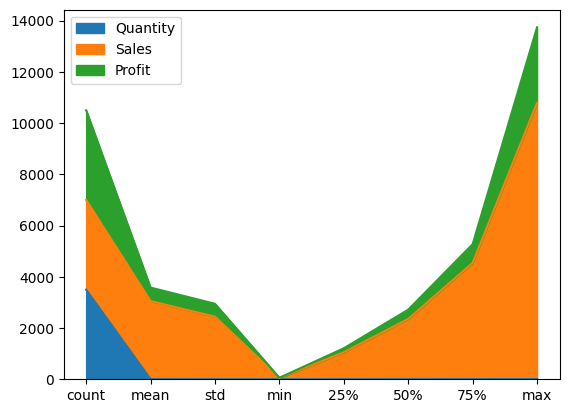

In [5]:
df.describe().plot(kind='area')

In [6]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month'] = df['Order Date'].dt.month 
df['month'].value_counts()

month
5     335
3     323
12    306
1     304
8     297
10    292
4     286
9     285
7     284
11    280
6     271
2     237
Name: count, dtype: int64

In [9]:
df['net'] = df['Sales']-df['Profit']
df['net'].head()

0    3291.07
1    1090.47
2    5362.27
3     583.13
4     405.72
Name: net, dtype: float64

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['year'] = df['Order Date'].dt.year 
df['year'].value_counts()

year
2023    1204
2024    1202
2022    1094
Name: count, dtype: int64

In [11]:
df.dtypes

Order Date      datetime64[ns]
Product Name            object
Category                object
Region                  object
Quantity                 int64
Sales                    int64
Profit                 float64
month                    int32
net                    float64
year                     int32
dtype: object

<Figure size 1000x1000 with 0 Axes>

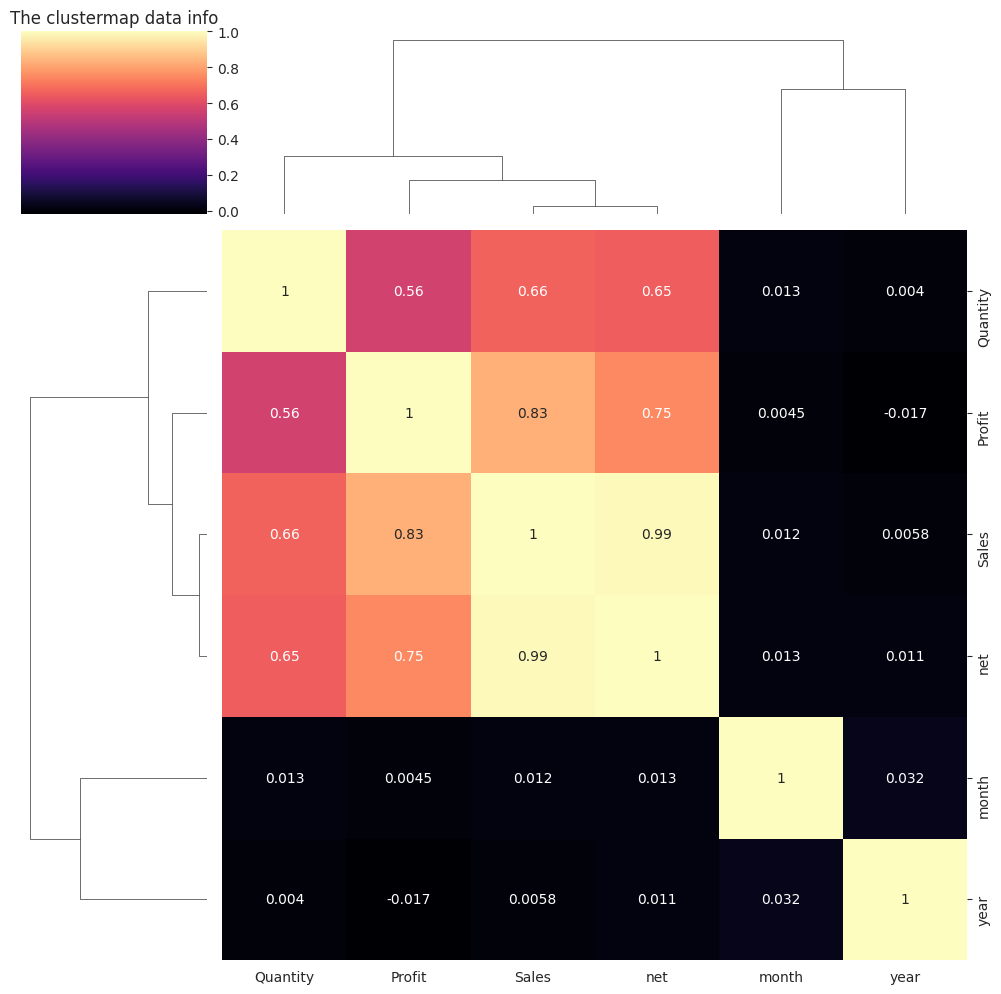

In [12]:
plt.figure(figsize=(10,10))
sns.set_style('darkgrid')
sns.clustermap(df.corr(numeric_only=True),annot=True,cmap='magma')
plt.title('The clustermap data info')
plt.grid(True)
plt.tight_layout()
plt.show()

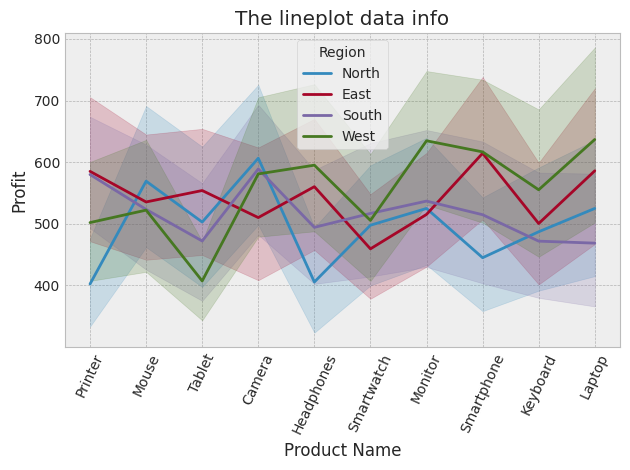

In [13]:
plt.style.use('bmh')
sns.lineplot(x='Product Name',y='Profit',data=df,hue='Region')
plt.title('The lineplot data info')
plt.xticks(rotation=65)
plt.grid(True)
plt.tight_layout()
plt.show()

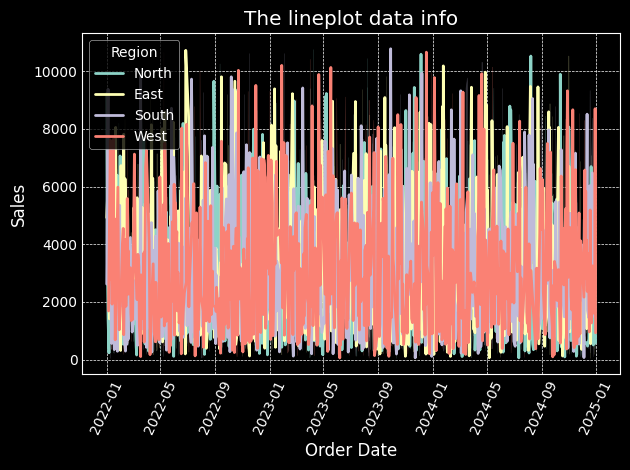

In [14]:
plt.style.use('dark_background')
sns.lineplot(x='Order Date',y='Sales',data=df,hue='Region')
plt.title('The lineplot data info')
plt.grid(True)
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()

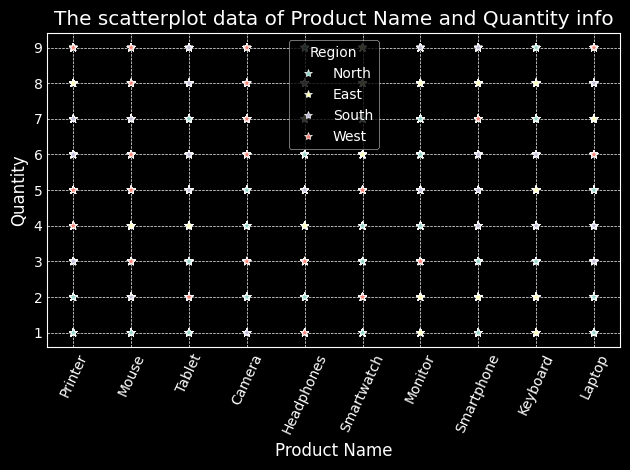

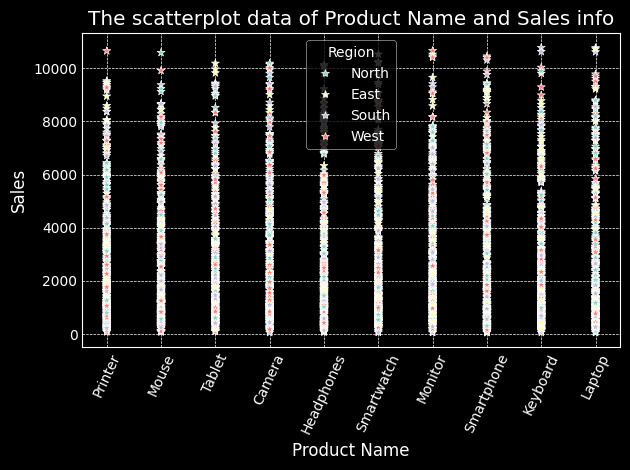

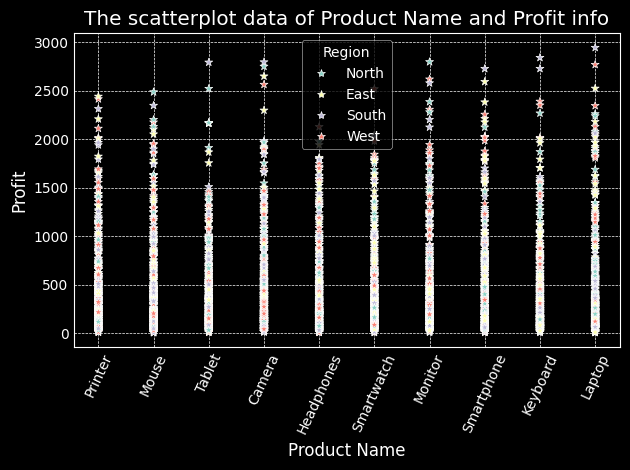

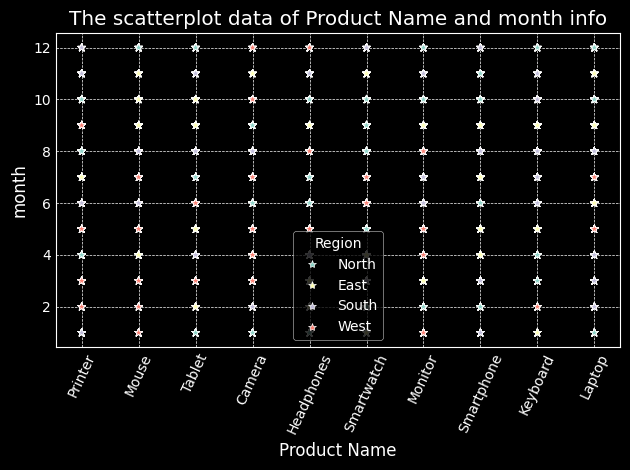

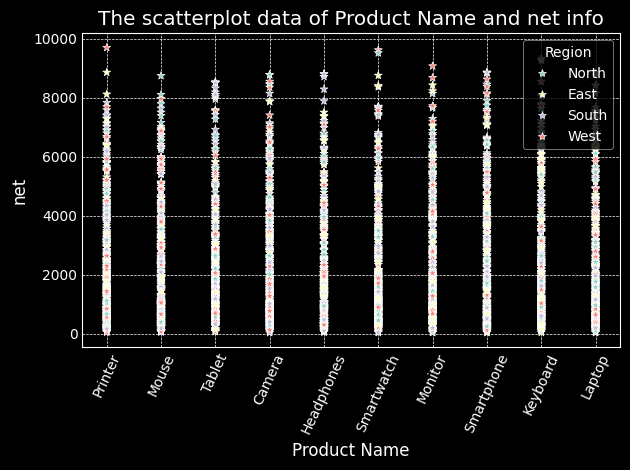

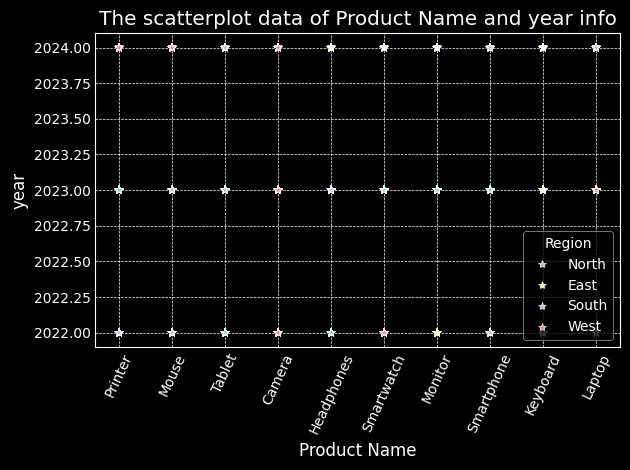

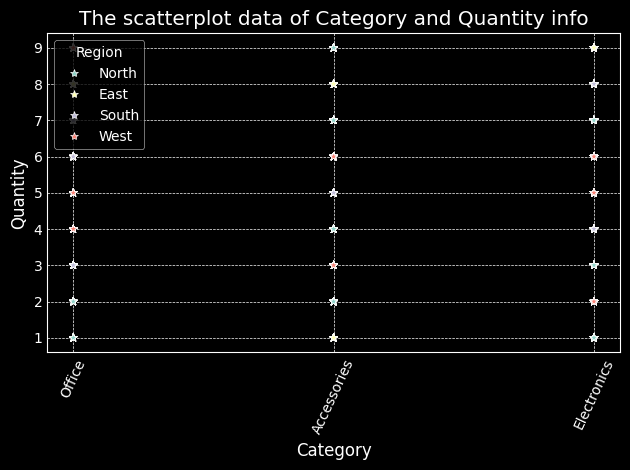

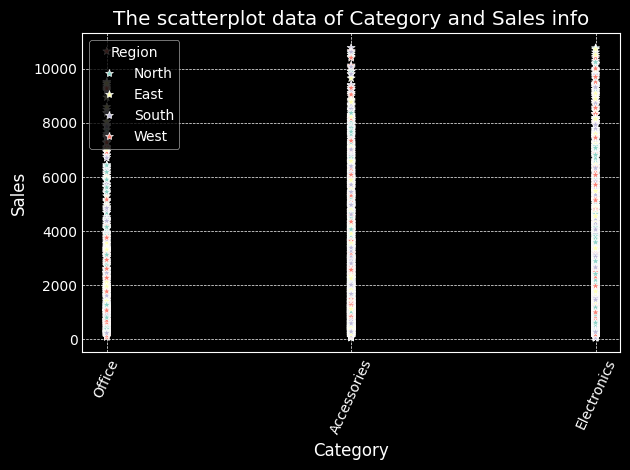

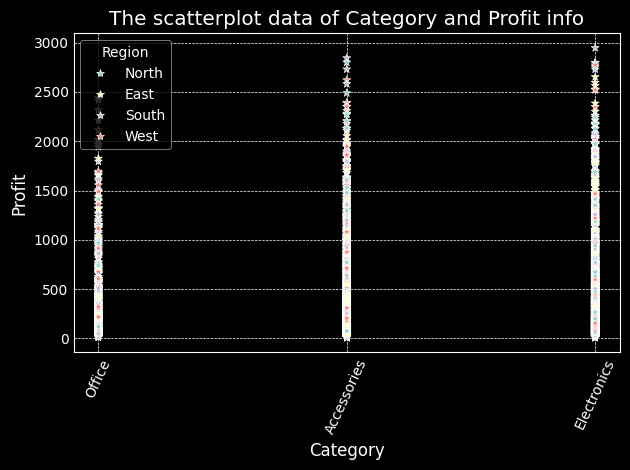

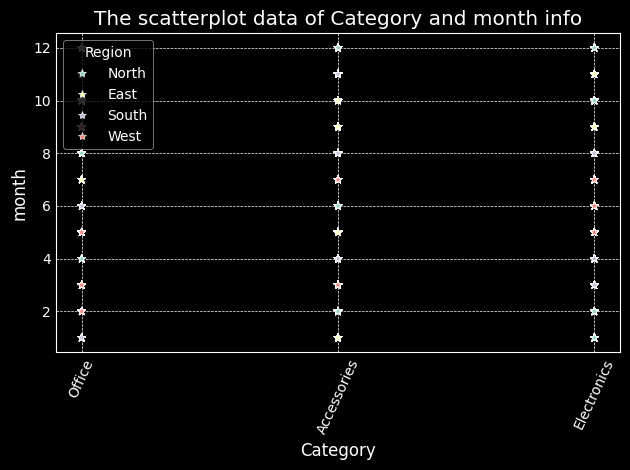

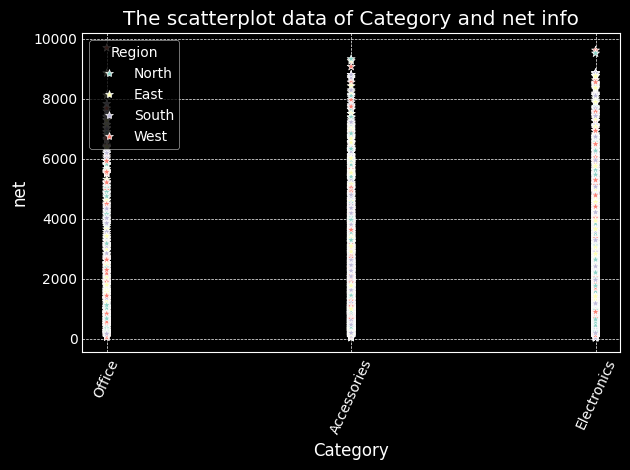

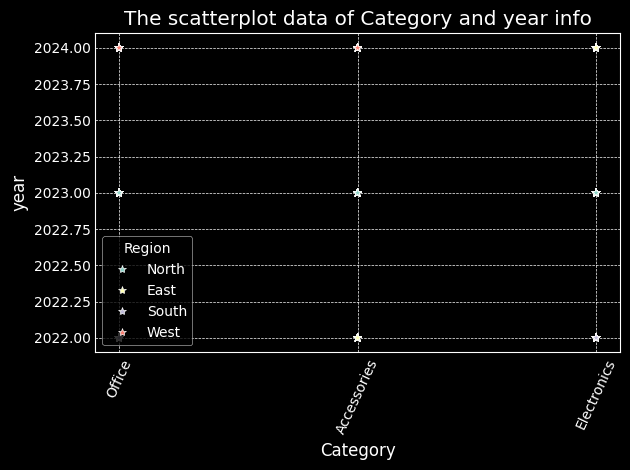

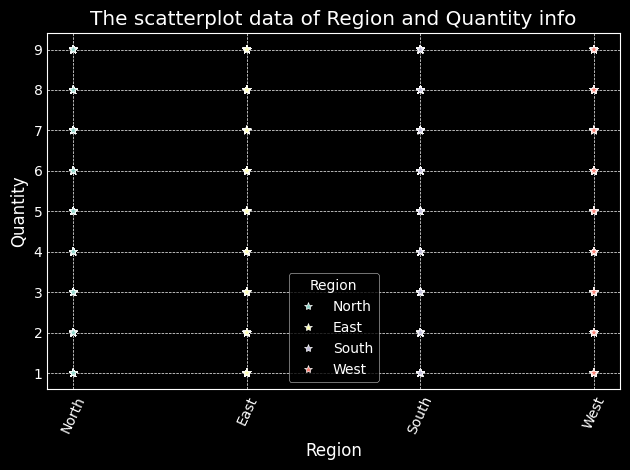

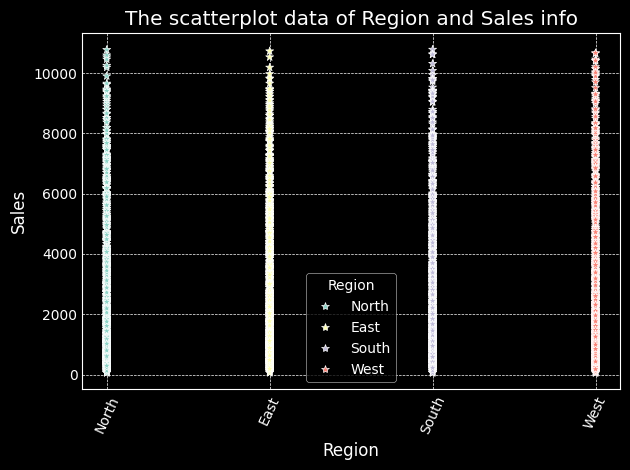

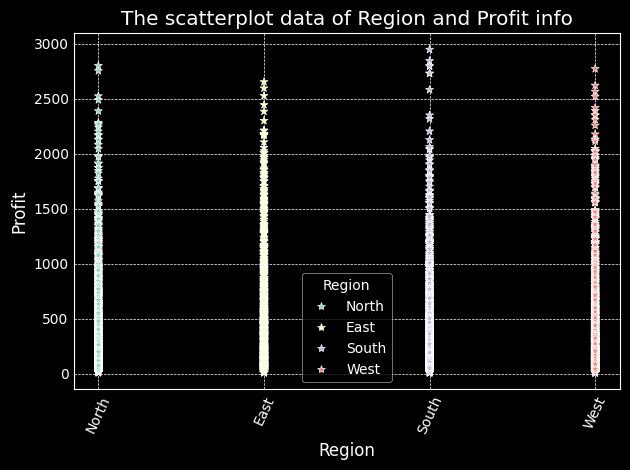

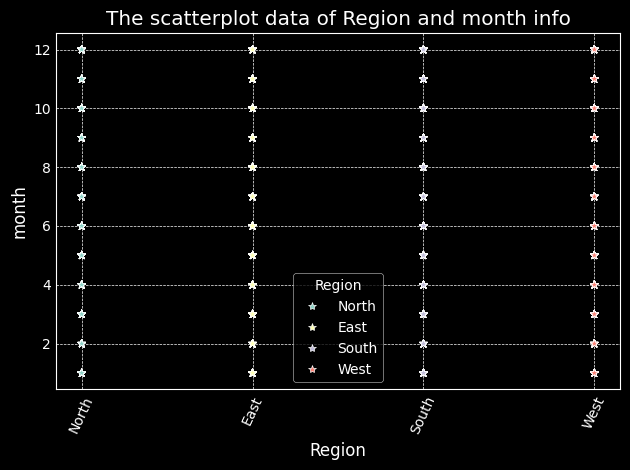

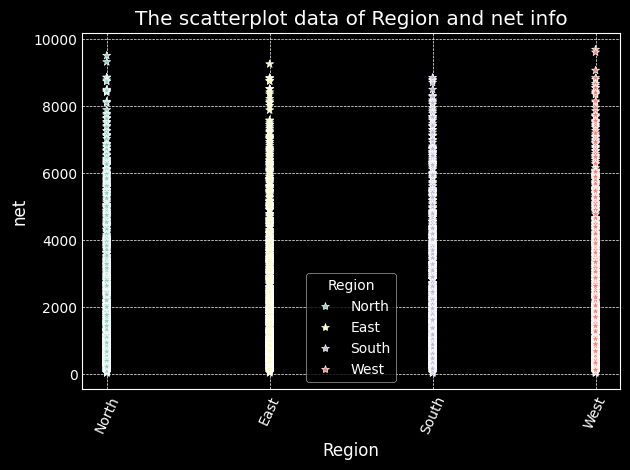

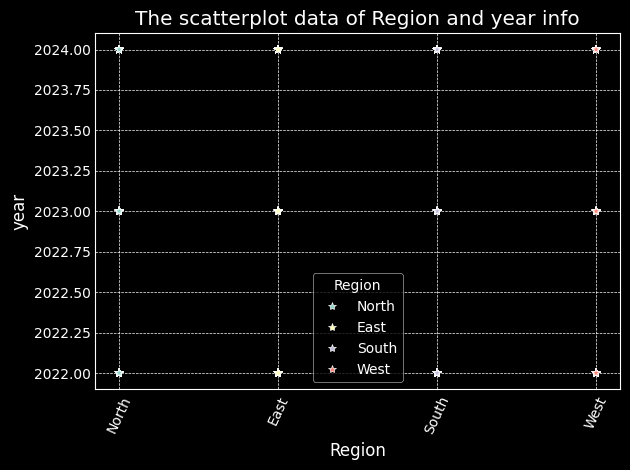

In [15]:
category_col = df.select_dtypes(include=['object']).columns 
numerical_col = df.select_dtypes(include=np.number).columns

plt.style.use('dark_background')
for col in category_col:
    for i in numerical_col:
        sns.scatterplot(x=col,y=i,data=df,hue='Region',marker='*')
        plt.title(f'The scatterplot data of {col} and {i} info')
        plt.xticks(rotation=65)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

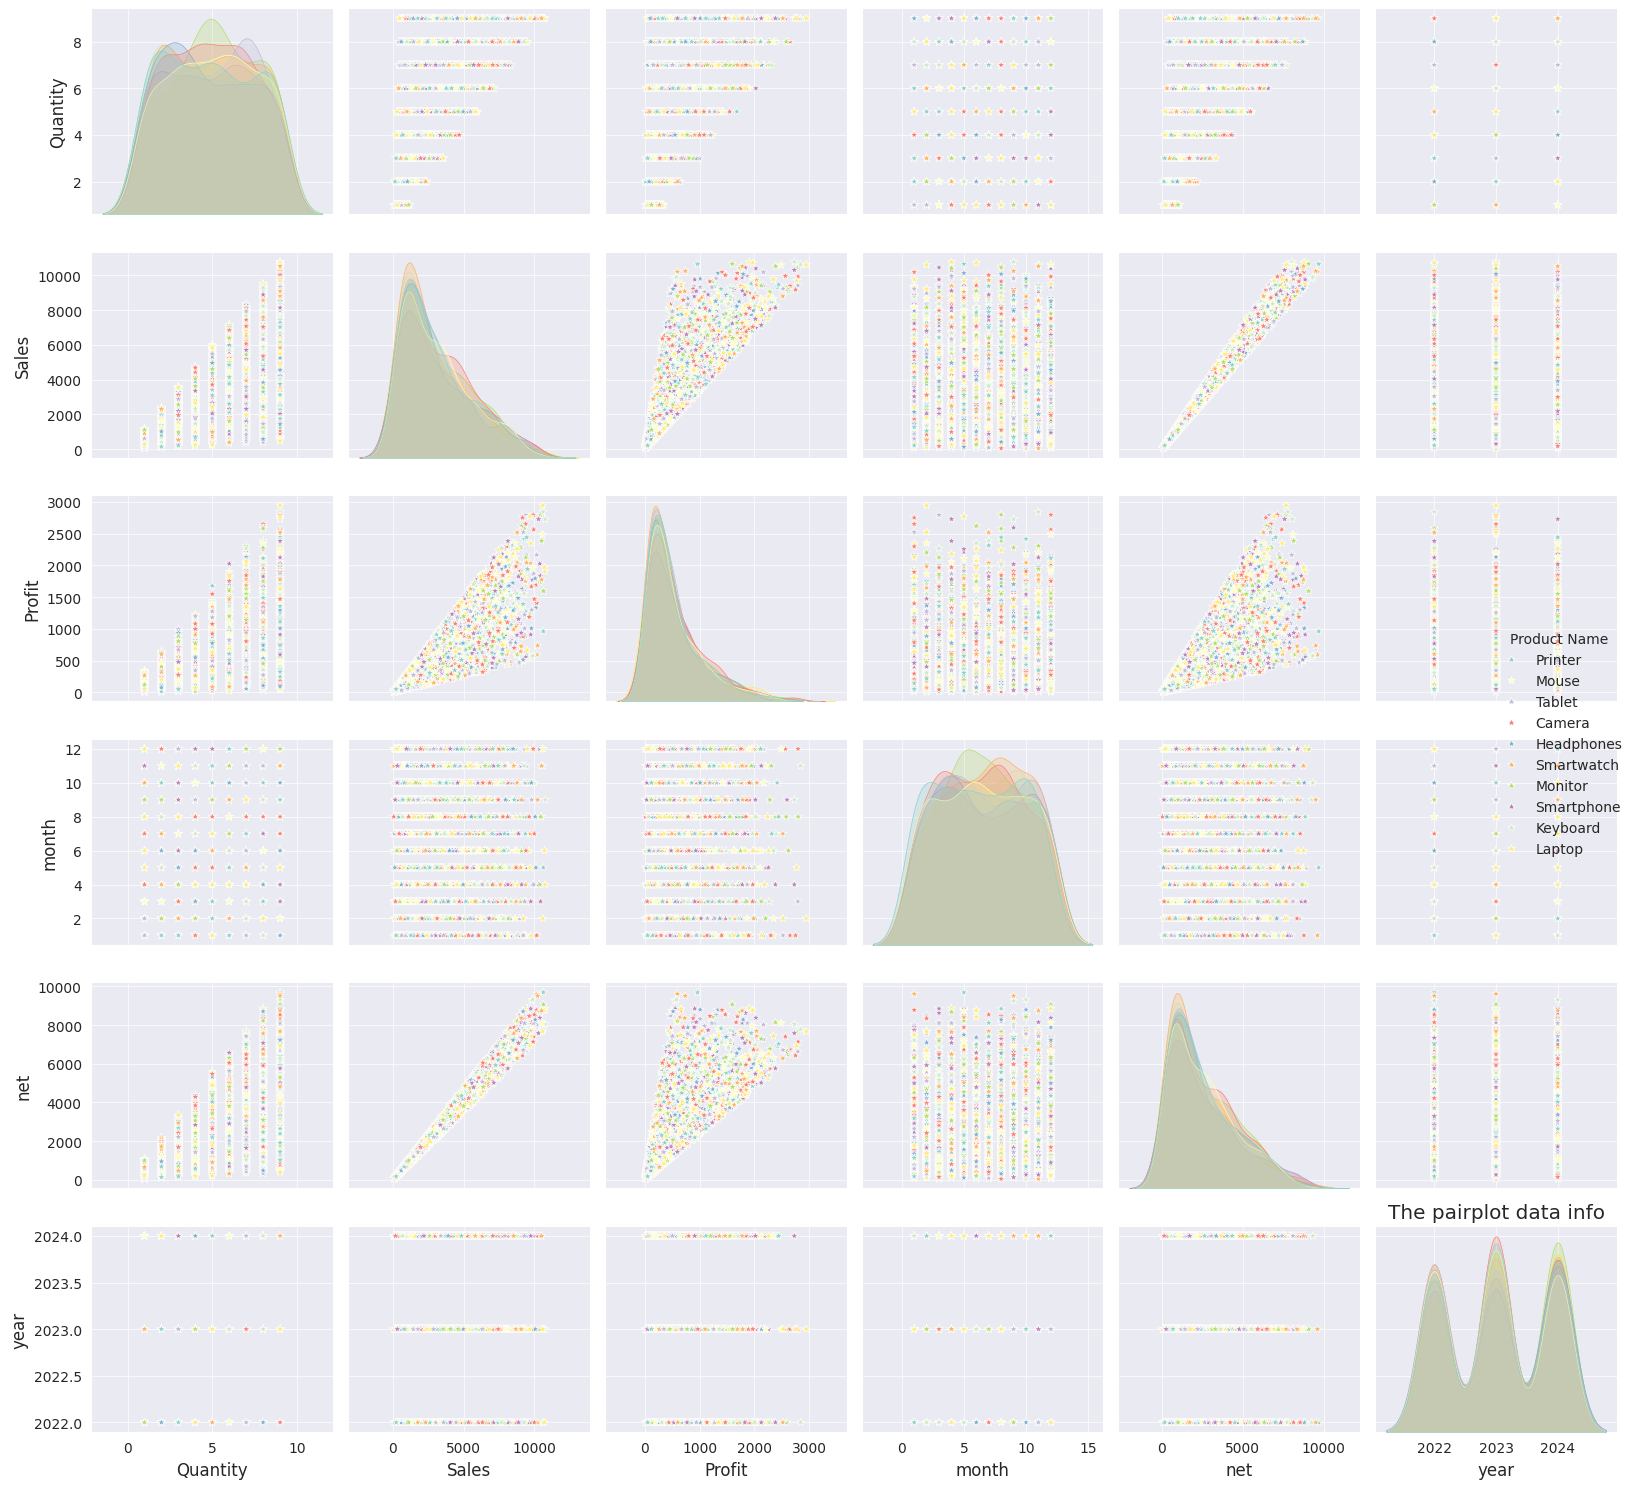

In [16]:
sns.set_style('darkgrid')
sns.pairplot(data=df,markers='*',hue='Product Name')
plt.title('The pairplot data info')
plt.grid(True)
plt.tight_layout()
plt.show()

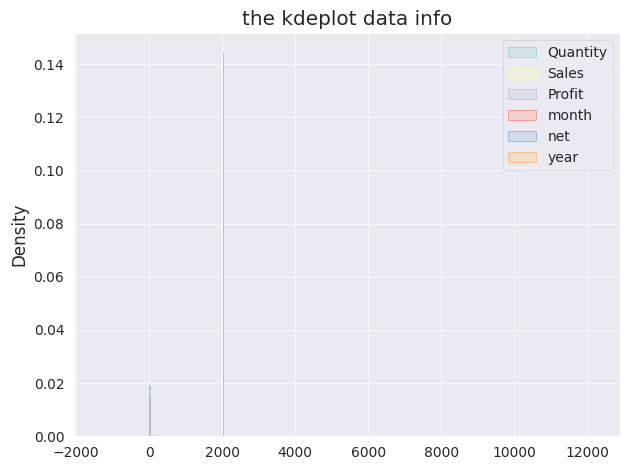

In [17]:
sns.set_style('darkgrid')
sns.kdeplot(data=df,fill=True)
plt.title('the kdeplot data info')
plt.grid(True)
plt.tight_layout()
plt.show()